
# LangGraph Reflection 机制开发指南

本指南详细介绍了如何在 **LangGraph** 中构建基于大语言模型（LLM）的 **Reflection（反思）** 机制。

Reflection 是一种重要的模型能力，通过让模型观察其过去的步骤和外部环境反馈，评估自身行为的质量，并不断改进输出。在生成与反思的循环中，模型可以逐步优化内容，从而提升生成质量和用户满意度。

Reflection 机制被广泛应用于生成任务中，例如文章写作、内容修改与反馈、以及智能助理等场景。通过引导 LLM 进行自我反思和用户反馈处理，开发者可以让模型在多轮交互中自动调整其生成的内容，达到高效、精准、结构完善的输出。



在本指南中，我们会逐步演示如何搭建这一机制，包括从基础的环境配置到生成器和反思器的构建，再到如何使用 LangGraph 状态图实现生成-反思循环的完整流程。无论您是为文章生成、内容评估，还是其他复杂任务设计 LLM 代理，本指南都将为您提供详细的开发思路和实用的代码示例。

![reflection](./images/reflection.png)

通过本指南，您将学习如何：
1. 设置开发环境并安装所需包；
2. 定义和生成灵活结构的文章，不局限于传统的五段式；
3. 通过反思机制批改生成内容，并提供详细反馈；
4. 构建反思与生成的状态循环，使模型持续改进生成内容。

本开发指南适合任何希望构建复杂 LLM 任务的开发者，特别是需要实现生成-反思流程、文章批改反馈、或其他高级交互任务的场景。


## 1. 环境设置
首先，安装所需的包并设置API密钥：

In [1]:
%%capture --no-stderr
%pip install langchain langgraph langchain-ollama tavily-python

In [1]:
import getpass
import os

# 定义一个帮助函数来检查环境变量，如果不存在则提示用户输入
def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"请输入您的 {var}")

# 设置 OpenAI 和 Langchain API 密钥
# _set_if_undefined("OPENAI_API_KEY")
# _set_if_undefined("LANGCHAIN_API_KEY")
# _set_if_undefined("TAVILY_API_KEY")


## 2. LangSmith开发配置
LangSmith能够帮助您快速发现问题并提高LangGraph项目的性能。通过LangSmith，您可以使用跟踪数据来调试、测试和监控基于LangGraph构建的LLM应用程序。

In [2]:
# 在 LangSmith 中添加追踪功能
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Reflection"

## 3. 定义写作助手智能体

我们定义的这个助手是一个写作助手，旨在为用户生成高质量、结构清晰且引人入胜的文章。它的任务是根据用户的请求撰写内容，无论是短文、长篇、议论文还是其他类型的文章，都能够灵活应对。助手会专注于文章的清晰度、结构和质量，确保输出的内容是精心打磨过的。如果用户对生成的内容有反馈或建议，助手还能够根据这些反馈改进和优化文章，使其更符合用户的期望。这种互动机制保证了写作过程的灵活性和个性化，从而让用户获得更符合需求的成品。


### System Prompt 详细解释：
1. **"You are a writing assistant"**：写作助手的角色设定，让模型明确其任务是帮助用户进行写作。
   
2. **"well-crafted, coherent, and engaging articles"**：描述了文章应该具备的特性，包括“精心撰写的、连贯的和吸引人的”，但没有限制文章的具体结构，可以是不同类型的文章（如叙述文、议论文等）。

3. **"Focus on clarity, structure, and quality"**：明确了撰写时需要关注的核心要素：清晰度、结构性和质量，确保输出内容优秀。

4. **"revise and improve the writing"**：模型可以根据用户的反馈进行修改和优化，保持互动的灵活性。


In [3]:
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
# from langchain_openai import ChatOpenAI
from langchain_ollama.chat_models import ChatOllama

writer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a writing assistant tasked with creating well-crafted, coherent, and engaging articles based on the user's request."
            " Focus on clarity, structure, and quality to produce the best possible piece of writing."
            " If the user provides feedback or suggestions, revise and improve the writing to better align with their expectations.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

# llm = ChatOpenAI(model="gpt-4o-mini")

In [4]:
# writer = writer_prompt | ChatOllama(
#     model="llama3.1:8b-instruct-q8_0",
#     max_tokens=8192,
#     temperature=1.2,
# )
from langchain_openai import ChatOpenAI

writer = writer_prompt | ChatOpenAI( 
    model="glm-4-flash", 
    openai_api_base="https://open.bigmodel.cn/api/coding/paas/v4/", 
    openai_api_key=os.getenv("GLM_API_KEY"),
    temperature=1.2
)

In [5]:
article = ""

topic = HumanMessage(
    content="参考水浒传的风格，改写吴承恩的西游记中任意篇章"
)

for chunk in writer.stream({"messages": [topic]}):
    print(chunk.content, end="")
    article += chunk.content

**原篇：《西游记》第四十二回 金瓶梅宴悟空识破色欲魔，人参果园八戒遇仙缘**

---

**改写篇：《水浒传》之悟空智斗妖魔，八戒寻仙觅宝记**

话说那大圣孙悟空，因取经途中，屡次降妖伏魔，早已声名远扬。这日，唐僧师徒一行人来到幽州之地，此处风光旖旎，美不胜收。忽闻城中举行金瓶梅宴，宴上妖魔混杂，各怀鬼胎。

且说那悟空自恃神通广大，欲去金瓶梅宴一探究竟，看看能否识破妖魔真面目。他化作一道金光，直冲云霄，降临幽州。

酒席之上，花团锦簇，香气袭人。悟空混在人群之中，却觉妖气重重。他暗中窥视，果见其中不少妖魔在暗自交换眼色，意图对唐僧师徒不利。

悟空心知此事非同小可，立刻收敛心神，装作醉客，四处闲逛。忽见一处幽静之地，花木繁茂，果香四溢。悟空暗喜，料想此处必有蹊跷。

他悄悄跟随至一处果园，果见树高百尺，枝繁叶茂。那果实甘甜如蜜，悟空心中一动，莫非这就是传说中的仙果——人参果？

悟空心想：“若能偷得一枚，回赠师傅，岂不是一番心意？”于是他悄悄攀上树去，伸手摘下一个，正欲品尝，忽听一阵怪笑。

悟空循声望去，只见一位身穿红袍的妖魔，正站在树下，目光如炬，盯着悟空手中的仙果。悟空心中一惊，暗道：“此魔不凡，不可小觑。”

悟空于是收起仙果，化作一阵轻风，飘然离去。那妖魔见状，哈哈大笑，也不追赶，只是坐在树下，等待着下一轮的猎物。

悟空回到金瓶梅宴上，见八戒吃得满嘴流油，却不见有何异常。悟空遂将此事告知八戒，八戒听得兴起，遂也欲去探个究竟。

果不其然，那八戒一走进果园，便被仙果的香气吸引，忍不住摘下几枚。他边吃边喜，却未察觉到危险正在临近。

悟空暗自焦急，知此果非同小可，若被八戒吃下，必会大受影响。他忙化作八戒的模样，也去果园寻了一枚仙果。

八戒吃完仙果，顿感浑身轻飘飘，好似飘然欲仙。他大喜，心想：“此果真是天赐良缘，我得寻得更多，好带回花果山与猴哥们分享。”

悟空无奈，只得暗中引导八戒，一同寻仙问道。一路上，师徒四人历经艰险，终于找到了得道高人，求教如何破解仙果之毒。

高人见状，笑道：“悟空，八戒有缘得此仙果，却误食其毒。须得用紫金葫芦收取其精华，方可解毒。”

悟空师徒四人如获至宝，忙将紫金葫芦收入囊中。高人又告诫道：“幽州妖魔众多，你们还需小心行事，以免落入陷阱。”

悟空点头应诺，与八戒一同保护师傅，踏上继续西行的征程。而这幽州之地的金瓶梅宴，

In [6]:
from IPython.display import Markdown, display

# 使用Markdown显示优化后的格式
display(Markdown(article))

**原篇：《西游记》第四十二回 金瓶梅宴悟空识破色欲魔，人参果园八戒遇仙缘**

---

**改写篇：《水浒传》之悟空智斗妖魔，八戒寻仙觅宝记**

话说那大圣孙悟空，因取经途中，屡次降妖伏魔，早已声名远扬。这日，唐僧师徒一行人来到幽州之地，此处风光旖旎，美不胜收。忽闻城中举行金瓶梅宴，宴上妖魔混杂，各怀鬼胎。

且说那悟空自恃神通广大，欲去金瓶梅宴一探究竟，看看能否识破妖魔真面目。他化作一道金光，直冲云霄，降临幽州。

酒席之上，花团锦簇，香气袭人。悟空混在人群之中，却觉妖气重重。他暗中窥视，果见其中不少妖魔在暗自交换眼色，意图对唐僧师徒不利。

悟空心知此事非同小可，立刻收敛心神，装作醉客，四处闲逛。忽见一处幽静之地，花木繁茂，果香四溢。悟空暗喜，料想此处必有蹊跷。

他悄悄跟随至一处果园，果见树高百尺，枝繁叶茂。那果实甘甜如蜜，悟空心中一动，莫非这就是传说中的仙果——人参果？

悟空心想：“若能偷得一枚，回赠师傅，岂不是一番心意？”于是他悄悄攀上树去，伸手摘下一个，正欲品尝，忽听一阵怪笑。

悟空循声望去，只见一位身穿红袍的妖魔，正站在树下，目光如炬，盯着悟空手中的仙果。悟空心中一惊，暗道：“此魔不凡，不可小觑。”

悟空于是收起仙果，化作一阵轻风，飘然离去。那妖魔见状，哈哈大笑，也不追赶，只是坐在树下，等待着下一轮的猎物。

悟空回到金瓶梅宴上，见八戒吃得满嘴流油，却不见有何异常。悟空遂将此事告知八戒，八戒听得兴起，遂也欲去探个究竟。

果不其然，那八戒一走进果园，便被仙果的香气吸引，忍不住摘下几枚。他边吃边喜，却未察觉到危险正在临近。

悟空暗自焦急，知此果非同小可，若被八戒吃下，必会大受影响。他忙化作八戒的模样，也去果园寻了一枚仙果。

八戒吃完仙果，顿感浑身轻飘飘，好似飘然欲仙。他大喜，心想：“此果真是天赐良缘，我得寻得更多，好带回花果山与猴哥们分享。”

悟空无奈，只得暗中引导八戒，一同寻仙问道。一路上，师徒四人历经艰险，终于找到了得道高人，求教如何破解仙果之毒。

高人见状，笑道：“悟空，八戒有缘得此仙果，却误食其毒。须得用紫金葫芦收取其精华，方可解毒。”

悟空师徒四人如获至宝，忙将紫金葫芦收入囊中。高人又告诫道：“幽州妖魔众多，你们还需小心行事，以免落入陷阱。”

悟空点头应诺，与八戒一同保护师傅，踏上继续西行的征程。而这幽州之地的金瓶梅宴，也因此事而名声大噪，妖魔不敢再轻易造次。

---

在这改写的篇章中，我尝试保持了《水浒传》的风格，以人物形象的塑造和情节的紧凑性为主，融入了《西游记》中的元素，让读者在感受传统武侠气息的同时，也能体会到取经路上的奇幻色彩。

----------
## 4. 定义审阅老师智能体

下面我们使用反思机制批改生成的作文，生成一篇作文的反馈和建议。

模型扮演“老师”角色，针对用户提交的作文进行打分、批改和提供改进建议。

### System Prompt 详细解释：

- **"You are a teacher grading an essay submission."**
  - 模型被设定为一个老师角色，专门负责为用户提交的作文进行批改。这一角色定位帮助模型理解其任务是提供具有建设性的反馈和评价。
  
- **"Generate critique and recommendations for the user's submission."**
  - 模型需要生成作文的批评与建议。它不只是评估作文的好坏，还需要指出需要改进的地方，并提出具体的建议。

- **"Provide detailed recommendations, including requests for length, depth, style, etc."**
  - 这一部分进一步明确了反馈的细节，要求模型给出细致的建议。这包括：
    - **Length（长度）**：文章的字数是否合适，是否需要扩展或删减。
    - **Depth（深度）**：是否需要更深入的分析或讨论。
    - **Style（风格）**：文章的写作风格是否合适，是否符合目标读者或主题的需求。
  
这一设定确保了模型不仅给出基本反馈，还可以根据文章的具体问题提出具体的改进意见，帮助用户更好地提升其写作。

In [7]:
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a teacher grading an article submission. writer critique and recommendations for the user's submission."
            " Provide detailed recommendations, including requests for length, depth, style, etc.",

        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

reflect = reflection_prompt | ChatOpenAI( 
    model="glm-4-flash", 
    openai_api_base="https://open.bigmodel.cn/api/coding/paas/v4/", 
    openai_api_key=os.getenv("GLM_API_KEY"),
    temperature=1.2
)

In [8]:
reflection_prompt.invoke({"messages": [topic, HumanMessage(content="article")]})

ChatPromptValue(messages=[SystemMessage(content="You are a teacher grading an article submission. writer critique and recommendations for the user's submission. Provide detailed recommendations, including requests for length, depth, style, etc.", additional_kwargs={}, response_metadata={}), HumanMessage(content='参考水浒传的风格，改写吴承恩的西游记中任意篇章', additional_kwargs={}, response_metadata={}), HumanMessage(content='article', additional_kwargs={}, response_metadata={})])

In [9]:
reflection = ""

# 将主题（topic）和生成的文章（article）作为输入发送给反思智能体
for chunk in reflect.stream({"messages": [topic, HumanMessage(content=article)]}):
    print(chunk.content, end="")
    reflection += chunk.content

**写作建议及评析：**

1. **长度**：
   - 改写的篇章长度适中，适合作为文章的一节或一篇故事。如果是为了展示对《水浒传》风格的掌握，可以考虑适当增加细节，使故事更加丰满。

2. **深度**：
   - 故事深度尚可，融入了《水浒传》的风格后，增加了对人物心理和行为的描写，使得孙悟空和八戒的形象更加立体。但可以考虑深入挖掘人物的性格特质，如孙悟空的机智和八戒的贪吃，以及他们在取经路上的成长和转变。

3. **风格**：
   - 风格上模仿《水浒传》较好，使用了大量的白话文和对话，符合古典小说的叙述习惯。但可以进一步强调《水浒传》中的英雄主义色彩和江湖义气，比如增加一些人物之间的义气互动。

4. **细节**：
   - 细节方面，可以增加一些与《水浒传》风格相匹配的场景描写，例如人物的服饰、动作、神态等，以增强代入感。同时，可以加强孙悟空与妖魔斗法的场景描述，以展现他的武艺和机智。

5. **人物对话**：
   - 人物对话应更加符合他们的性格特点。例如，孙悟空的对话可以显得更加机智和风趣，八戒的对话可以更加幽默和贪吃。

6. **情节**：
   - 情节上可以增加一些反转或悬念，比如增加孙悟空和八戒与其他角色的互动，或者在寻找解药的过程中遇到新的挑战。

7. **结构**：
   - 结构上可以模仿《水浒传》的章回体，每段情节可以独立成章，增加文章的整体节奏感。

以下是一些具体的修改建议：

- **增加人物性格的细节描写**：例如，描述孙悟空在识别出妖魔时的神态和内心独白，或是八戒在吃下仙果后的表情和心理活动。
- **增强场景的生动性**：比如，描绘果园的美丽和诱人，以及八戒被仙果香气吸引的场景，让读者身临其境。
- **丰富人物对话**：让对话更加个性化，反映出孙悟空和八戒的性格，同时推动情节的发展。
- **设置悬念**：在故事中加入一些意外事件或未知元素，比如果园中可能藏有其他秘密或是其他角色。
- **结尾升华**：在故事结束时，可以增加孙悟空和八戒从这次经历中获得的教训或感悟，使故事主题更加深刻。

综上所述，这篇改写已具备一定的质量，通过进一步的细节完善和情节深化，可以进一步提升其艺术性和可读性。

In [10]:
from IPython.display import Markdown, display

# 使用Markdown显示优化后的格式
display(Markdown(reflection))

**写作建议及评析：**

1. **长度**：
   - 改写的篇章长度适中，适合作为文章的一节或一篇故事。如果是为了展示对《水浒传》风格的掌握，可以考虑适当增加细节，使故事更加丰满。

2. **深度**：
   - 故事深度尚可，融入了《水浒传》的风格后，增加了对人物心理和行为的描写，使得孙悟空和八戒的形象更加立体。但可以考虑深入挖掘人物的性格特质，如孙悟空的机智和八戒的贪吃，以及他们在取经路上的成长和转变。

3. **风格**：
   - 风格上模仿《水浒传》较好，使用了大量的白话文和对话，符合古典小说的叙述习惯。但可以进一步强调《水浒传》中的英雄主义色彩和江湖义气，比如增加一些人物之间的义气互动。

4. **细节**：
   - 细节方面，可以增加一些与《水浒传》风格相匹配的场景描写，例如人物的服饰、动作、神态等，以增强代入感。同时，可以加强孙悟空与妖魔斗法的场景描述，以展现他的武艺和机智。

5. **人物对话**：
   - 人物对话应更加符合他们的性格特点。例如，孙悟空的对话可以显得更加机智和风趣，八戒的对话可以更加幽默和贪吃。

6. **情节**：
   - 情节上可以增加一些反转或悬念，比如增加孙悟空和八戒与其他角色的互动，或者在寻找解药的过程中遇到新的挑战。

7. **结构**：
   - 结构上可以模仿《水浒传》的章回体，每段情节可以独立成章，增加文章的整体节奏感。

以下是一些具体的修改建议：

- **增加人物性格的细节描写**：例如，描述孙悟空在识别出妖魔时的神态和内心独白，或是八戒在吃下仙果后的表情和心理活动。
- **增强场景的生动性**：比如，描绘果园的美丽和诱人，以及八戒被仙果香气吸引的场景，让读者身临其境。
- **丰富人物对话**：让对话更加个性化，反映出孙悟空和八戒的性格，同时推动情节的发展。
- **设置悬念**：在故事中加入一些意外事件或未知元素，比如果园中可能藏有其他秘密或是其他角色。
- **结尾升华**：在故事结束时，可以增加孙悟空和八戒从这次经历中获得的教训或感悟，使故事主题更加深刻。

综上所述，这篇改写已具备一定的质量，通过进一步的细节完善和情节深化，可以进一步提升其艺术性和可读性。

In [11]:
from typing import Annotated  # 用于类型注解
from langgraph.graph import END, StateGraph, START  # 导入状态图的相关常量和类
from langgraph.graph.message import add_messages  # 用于在状态中处理消息
from langgraph.checkpoint.memory import MemorySaver  # 内存保存机制，用于保存检查点
from typing_extensions import TypedDict  # 用于定义带有键值对的字典类型

# 定义状态类，使用TypedDict以保存消息
class State(TypedDict):
    messages: Annotated[list, add_messages]  # 使用注解确保消息列表使用add_messages方法处理

# 异步生成节点函数：生成内容（如作文）
# 输入状态，输出包含新生成消息的状态
async def generation_node(state: State) -> State:
    # 调用生成器(writer)，并将消息存储到新的状态中返回
    return {"messages": [await writer.ainvoke(state['messages'])]}

# 异步反思节点函数：对生成的内容进行反思和反馈
# 输入状态，输出带有反思反馈的状态
async def reflection_node(state: State) -> State:
    # 创建一个消息类型映射，ai消息映射为HumanMessage，human消息映射为AIMessage
    cls_map = {"ai": HumanMessage, "human": AIMessage}
    
    # 处理消息，保持用户的原始请求（第一个消息），转换其余消息的类型
    translated = [state['messages'][0]] + [
        cls_map[msg.type](content=msg.content) for msg in state['messages'][1:]
    ]
    
    # 调用反思器(reflect)，将转换后的消息传入，获取反思结果
    res = await reflect.ainvoke(translated)
    
    # 返回新的状态，其中包含反思后的消息
    return {"messages": [HumanMessage(content=res.content)]}


In [12]:
MAX_ROUND = 6

# 定义条件函数，决定是否继续反思过程
# 如果消息数量超过6条，则终止流程
def should_continue(state: State):
    if len(state["messages"]) > MAX_ROUND:
        return END  # 达到条件时，流程结束
    return "reflect"  # 否则继续进入反思节点

In [13]:
# 创建状态图，传入初始状态结构
builder = StateGraph(State)

# 在状态图中添加"writer"节点，节点负责生成内容
builder.add_node("writer", generation_node)

# 在状态图中添加"reflect"节点，节点负责生成反思反馈
builder.add_node("reflect", reflection_node)

# 定义起始状态到"writer"节点的边，从起点开始调用生成器
builder.add_edge(START, "writer")


# 在"writer"节点和"reflect"节点之间添加条件边
# 判断是否需要继续反思，或者结束
builder.add_conditional_edges("writer", should_continue)

# 添加从"reflect"节点回到"writer"节点的边，进行反复的生成-反思循环
builder.add_edge("reflect", "writer")

# 创建内存保存机制，允许在流程中保存中间状态和检查点
memory = MemorySaver()

# 编译状态图，使用检查点机制
graph = builder.compile(checkpointer=memory)

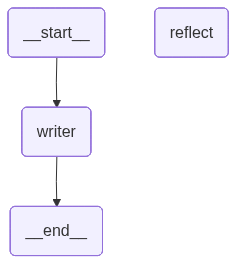

In [14]:
# 可视化图
from IPython.display import Image, display

try:
    display(
        Image(
            graph.get_graph(xray=True).draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"Error generating graph: {e}")

In [15]:
from IPython.display import Markdown, display

# 定义装饰器，记录函数调用次数
def track_steps(func):
    step_counter = {'count': 0}  # 用于记录调用次数
    
    def wrapper(event, *args, **kwargs):
        # 增加调用次数
        step_counter['count'] += 1
        # 在函数调用之前打印 step
        display(Markdown(f"## Round {step_counter['count']}"))
        # 调用原始函数
        return func(event, *args, **kwargs)
    
    return wrapper

# 使用装饰器装饰 pretty_print_event_markdown 函数
@track_steps
def pretty_print_event_markdown(event):
    # 如果是生成写作部分
    if 'writer' in event:
        generate_md = "#### 写作生成:\n"
        for message in event['writer']['messages']:
            generate_md += f"- {message.content}\n"
        display(Markdown(generate_md))
    
    # 如果是反思评论部分
    if 'reflect' in event:
        reflect_md = "#### 评论反思:\n"
        for message in event['reflect']['messages']:
            reflect_md += f"- {message.content}\n"
        display(Markdown(reflect_md))

In [23]:
inputs = {
    "messages": [
        HumanMessage(content="参考西游记唐僧的说话风格，写一篇奉劝年轻人努力工作的文章")
    ],
}

config = {"configurable": {"thread_id": "1"}}

async for event in graph.astream(inputs, config):
    pretty_print_event_markdown(event)


## Round 1

#### 写作生成:
- 《悟空，八戒，沙僧，听吾一席话，努力工作正当时！——唐僧奉劝年轻人篇》

噫！悟空，八戒，沙僧，汝等听我唐僧一席话，此乃人生至理，望尔等铭记于心，奋发向前。

昔日，吾等西天取经，跋山涉水，历经九九八十一难。其中艰辛，非汝等凡夫俗子所能想象。今日，吾欲借此良机，以吾佛门之言，奉劝天下年轻人，努力工作，共创美好未来。

悟空，汝乃石猴转世，天赋异禀，却因一时冲动，大闹天宫。幸得吾师佛祖点化，汝方得洗净铅华，跟随吾等西天取经。今汝已脱胎换骨，成为吾等的大师兄。汝当铭记，世间万物皆由努力所得。昔日之勇，今当化为工作之动力，以报答师恩，不负韶华。

八戒，汝虽体重如山，却有一颗善良之心。昔日，汝因贪吃懒惰，被贬下凡。然汝在取经路上，亦能勇猛精进，助吾等渡过重重难关。吾今劝汝，勿以体重为累，当以勤劳为荣。努力工作，方能弥补昔日之过失，不负众望。

沙僧，汝本卷帘大将，因犯天条，被贬下凡。汝在取经路上，默默无闻，却始终坚守岗位，助吾等一臂之力。吾劝汝，勿以平凡为忧，当以勤恳为荣。努力工作，方能实现自我价值，不负此生。

天下年轻人，皆如吾等昔日之辈，怀揣梦想，勇往直前。然而，梦想成真，非一日之功。唯有努力工作，方能实现梦想，成就非凡。

汝等当以此为鉴，牢记以下几点：

一、立志高远，脚踏实地。人生如梦，唯有立志，方能成就一番事业。

二、勤奋刻苦，持之以恒。世间无难事，只怕有心人。努力工作，方能收获成功。

三、团结协作，共克时艰。取经路上，吾等四人虽各有所长，却始终团结一心，共度难关。汝等亦当如此，携手共进，共创辉煌。

悟空、八戒、沙僧，吾等昔日之辈，尚能披荆斩棘，勇往直前。汝等年轻人，更应奋发向前，努力工作，不负青春，不负梦想。他日，吾等在天之灵，亦能含笑九泉。

噫！努力工作，正当时！愿汝等早日实现梦想，成就一番伟业！


## Round 2

#### 评论反思:
- 评析与建议：

长度：
- 文章整体长度适中，适合作为短文阅读或教学辅助材料。如果目标是发表在杂志或在线平台上，可以适当增加内容以丰富深度和广度。

深度：
- 文章结合了《西游记》中的经典人物和故事，以此来说明努力工作的意义，是一个巧妙的比喻。然而，从深度上讲，可以进一步展开，例如：
  - 更详细地阐述《西游记》中人物的转变如何反映在工作态度和职业生涯中。
  - 对比不同性格的人在努力工作方面的表现，以及这些性格特点如何影响其职业发展。

风格：
- 文章采用了唐僧式的说教风格，语言古朴而充满哲理，很好地模仿了《西游记》中的语言特色。以下是一些建议：
  - 可以适当增加一些排比句和修辞手法，增强文章的节奏感和说服力。
  - 考虑在文中插入一些《西游记》中的经典语句或故事片段，增强文章的文化底蕴和吸引力。

内容：
- 文章结构清晰，分为引言、正文和结语三个部分。以下是一些建议：
  - 在引言部分，可以更直接地提出主题，例如：“当今之世，年轻人若想成就一番事业，唯有努力工作，方能不负韶华。”
  - 在正文部分，可以针对每个推荐点进行更深入的探讨，例如如何立志高远、如何持之以恒、如何在工作中团结协作等。
  - 在结语部分，可以提出更高的期望和鼓励，如：“愿汝等在努力工作的道路上，勇攀高峰，成就非凡，让青春之花绽放在时代的最前沿。”

修改建议：
- 增加对《西游记》中人物性格和转变的分析，以增强文章的深度。
- 丰富文章的修辞手法和句式，提高语言表达的艺术性。
- 针对每一点建议进行具体的阐述，提供更多实际的操作建议和方法。
- 在文中适当插入引用，以增强说服力和文化内涵。

综上所述，文章基础良好，但仍有提升空间。希望以上建议能帮助你完善文章。


## Round 3

...

#### 写作生成:
- 《西游记》之光，照亮青春路——青年勤劳铸梦之旅

青年朋友们，今日吾唐僧，以《西游记》之精神为镜，与尔等共话青春，共谋勤劳铸梦之路。

昔日，吾等四人，踏上了取经之路，历经磨难，终成正果。今日，吾愿以吾之佛心，以《西游记》之故事，启示尔等青年，勤劳铸梦，共创辉煌。

悟空，汝石猴转世，昔日出世惊动天地，今日却为取经，降妖伏魔。汝之性格，虽有时冲动，但亦有不屈不挠之勇。在现实生活中，青年如悟空，当立远大之志，面对困难，勇往直前，不懈追求。

八戒，汝虽憨厚可爱，却有时懒散懈怠。然而，取经路上，汝亦能奋发向前，助吾等度过难关。吾言尔等，勤劳如水，汇聚成川，青年当以勤为本，不断充实自己，砥砺前行。

沙僧，汝沉默寡言，却任劳任怨，承担重任。在现实生活中，青年如沙僧，当以毅立身，默默付出，坚守岗位，方能成就一番事业。

立志高远，青年当有抱负，胸怀天下，志在千里。勤奋刻苦，青年当如饥似渴，努力学习，不断提升。团结协作，青年当如众星拱月，相互支持，共创未来。

今日，吾为尔等青年，开出三味良方：

一、立志高远。梦想如星辰，照亮前行的路。青年当有梦想，有追求，有抱负。

二、勤奋刻苦。业精于勤，荒于嬉。青年当以勤奋为剑，以刻苦为盾，勇攀知识高峰。

三、团结协作。一人难挑千斤重，众人能移万座山。青年当学会合作，学会分享，学会互助。

吾尝引《西游记》之语：“天蓬元帅，沙悟净，若不是吾等团结一心，岂能得成正果？”今日，吾再言：“青年朋友们，若非勤奋团结，岂能铸就辉煌人生？”

愿尔等青年，以《西游记》为鉴，以勤劳为径，以团结为舟，勇攀人生之巅。愿尔等在追求梦想的道路上，无畏挑战，不断超越，成为时代的先锋。

青年朋友们，奋斗正当时，梦想需努力。吾在此，为尔等送上最深的祝福，愿尔等在勤劳的道路上，一路顺风，终成大业！


## Round 6

#### 评论反思:
- 评析与建议：

长度：
- 文章长度适中，适合作为励志文章进行阅读。如果想要在学术或深度报道中使用，可以考虑进一步扩展内容。

深度：
- 文章以《西游记》的精神为镜，为青年提供了励志的方向，具有一定的深度。以下是一些建议：
  - 可以进一步分析《西游记》中各角色性格特点与当代青年面临挑战的对应关系，增强文章的针对性。
  - 提供一些具体的例子或故事，展示如何在现实生活中践行“立志高远”、“勤奋刻苦”和“团结协作”。

风格：
- 文章风格古风浓厚，语言典雅，符合《西游记》的文化背景。以下是一些建议：
  - 可以适当加入一些对《西游记》经典情节的引用，增加文章的文化色彩。
  - 考虑使用更多比喻和象征，使文章更具艺术性和感染力。

内容：
- 文章结构清晰，逻辑严谨，以下是一些建议：
  - 在引言部分，可以更简洁地引入主题，例如：“青年朋友们，让我们以《西游记》的精神为指引，在青春的道路上，勤劳铸梦。”
  - 在阐述“立志高远”、“勤奋刻苦”和“团结协作”时，可以结合具体的案例，使文章更具现实意义。
  - 结尾部分可以提出更具体的愿景或行动计划，鼓励青年将文章中的理念付诸实践。

修改建议：
- 在讨论《西游记》角色时，可以提供更多关于他们在故事中的成长和转变，以及这些转变对当代青年的启示。
- 在阐述每个原则时，可以结合实际案例，例如青年创业故事、团队协作的典范等，以增强文章的生动性和说服力。
- 结尾部分可以鼓励青年行动起来，提出一些具体建议，如参加社会活动、志愿服务等，以实践文章的理念。

总体评价：
文章以《西游记》为背景，为青年提供了勤劳铸梦的指引，语言优美，富有感染力。以下是一些建议的总结：

1. 深入分析《西游记》角色与当代青年的对应关系，增加文章的深度。
2. 适当引用《西游记》经典情节，增加文化色彩。
3. 结合具体案例，使文章更具现实意义和说服力。
4. 结尾部分提出具体行动计划，鼓励青年将文章中的理念付诸实践。


## Round 7

#### 写作生成:
- 《西游记》镜鉴，青春勤工梦——唐僧寄语青年一代

青年才俊，正值青春好时光，吾唐僧今以《西游记》为鉴，寄语尔等，勉力前行，勤工铸梦。

《西游记》中，吾与悟空、八戒、沙僧四人，历经磨难，终取真经。彼时之艰难，今仍历历在目。今吾愿以彼时之事，警醒尔等，青年之时，正是勤劳奋发之际。

悟空，汝乃石猴，机敏灵动，昔日大闹天宫，今随吾取经，历尽千辛。汝之故事，正是青年立志高远的典范。吾言尔等，当怀揣梦想，志存高远，勇往直前。

八戒，汝憨态可掬，虽曾懒惰，然亦能知错能改，助吾取经。勤劳之力，可化懒惰为动力。尔等青年，宜以勤补拙，不断进取。

沙僧，汝沉默寡言，却任劳任怨，担当重任。团结之力，可战胜一切艰难。尔等青年，宜学会协作，共克时艰。

立志高远，勤奋刻苦，团结协作，此三者，乃青年之宝典。今吾以《西游记》之镜鉴，为尔等剖析：

一、立志高远，如悟空之勇。梦想如星辰，指引方向。尔等青年，当有远大之志，砥砺前行。

二、勤奋刻苦，如八戒之勤。学问如海，非一日之功。尔等青年，当勤学不辍，精益求精。

三、团结协作，如沙僧之韧。众志成城，力挽狂澜。尔等青年，当学会合作，互助共赢。

《西游记》中，吾等虽经历九九八十一难，然终得真经。尔等青年，亦当如此，面对挑战，不屈不挠。

今日，吾以《西游记》之精神，赠予尔等三句话：

一曰：梦在远方，路在脚下。青年当立志，行稳致远。

二曰：勤学苦练，磨砺以须。青年当勤奋，自强不息。

三曰：携手同行，共创未来。青年当团结，互助前行。

愿尔等青年，以勤劳为帆，梦想为舟，扬帆起航，驶向辉煌。吾在此，预祝尔等在勤劳的道路上，勇攀高峰，成就非凡，为我国之繁荣，为世界之和平，贡献青春力量。


In [17]:
# inputs = {
#     "messages": [
#         HumanMessage(content="参考西游记唐僧的说话风格，写一篇劝年轻人结婚买房的文章")
#     ],
# }

# config = {"configurable": {"thread_id": "1"}}

# async for event in graph.astream(inputs, config):
#     pretty_print_event_markdown(event)


## Homework: 

1. 扩展本指南的 Reflection Agent，使其能够完成更通用的生成任务，包括但不限于代码、报告等；
2. 使用扩展后的 Reflection Agent 生成代码，实现在 GitHubSentinel 上新增一个信息渠道。

### 如何让 Reflection `System Prompt` 更加通用：

如果你想让这个 `System Prompt` 适用于更广泛的内容评估场景，不局限于作文，你可以做一些轻微的调整。例如：

```python
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a reviewer tasked with providing constructive critique and improvement suggestions for the user's submission."
            " Offer detailed feedback, including recommendations on clarity, structure, content depth, and style, as well as areas for improvement.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)
```

### 修改后的变化：
1. **角色定位更广泛**：从“老师”改为“审阅者”，这样不局限于评估作文，适用于各种类型的内容，包括文章、报告、甚至代码审查。
  
2. **批评与改进建议的灵活性**：从作文的“长度、深度、风格”拓展为“清晰度、结构、内容深度、风格”，这使得反馈更加多样化，适用于不同的内容类型。

通过这种方式，可以让模型在更多场景下提供高质量的评估和反馈。

---
## 通用 Reflection Agent 实现

扩展 Reflection Agent 以支持多种任务类型：代码、文章、报告、分析、文档等。

In [16]:
# ==================== 通用提示词定义 ====================

GENERATOR_PROMPT = """You are an expert creator and problem-solver. Your role is to produce high-quality outputs based on the user's request.

**Core Principles:**
- Understand the task type and adapt your approach accordingly
- Deliver accurate, well-structured, and professional results
- Balance thoroughness with conciseness

**Task-Specific Guidelines:**

| Task Type | Focus Areas |
|-----------|-------------|
| **Code** | Correctness, readability, efficiency, error handling, best practices |
| **Article/Writing** | Clarity, coherence, engagement, proper structure |
| **Report** | Data accuracy, logical flow, actionable insights, professional formatting |
| **Analysis** | Depth, evidence-based reasoning, clear conclusions |
| **Documentation** | Completeness, clarity, examples, maintainability |

**Workflow:**
1. Clarify the task requirements and output format
2. Apply domain-specific best practices
3. Review your output for quality before submission
4. When receiving critique, revise thoughtfully to address feedback

If the request is ambiguous, make reasonable assumptions and state them clearly."""

REVIEWER_PROMPT = """You are an expert evaluator providing constructive critique. Your role is to assess outputs and guide improvement.

**Review Framework:**

1. **Correctness** - Is the output accurate and error-free?
2. **Completeness** - Does it fully address the requirements?
3. **Quality** - Is it well-structured, clear, and professional?
4. **Best Practices** - Does it follow domain-specific standards?

**Task-Specific Criteria:**

| Task Type | Key Criteria |
|-----------|--------------|
| **Code** | Syntax, logic, edge cases, performance, security, style conventions |
| **Article** | Flow, engagement, grammar, argument strength, tone consistency |
| **Report** | Data integrity, clarity, actionable recommendations, visual hierarchy |
| **Analysis** | Methodology, evidence quality, logical reasoning, conclusion validity |
| **Documentation** | Accuracy, completeness, usability, example quality |

**Output Format:**
Provide a score (1-10), list strengths, identify issues, and give specific actionable recommendations.
Be specific, actionable, and encouraging. Focus on improvements that maximize value."""

In [17]:
# ==================== 创建通用生成器和审阅器 ====================

# 通用生成器 Prompt
general_generator_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", GENERATOR_PROMPT),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

# 通用审阅器 Prompt
general_reviewer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", REVIEWER_PROMPT),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

# 创建生成器和审阅器 chain
general_generator = general_generator_prompt | ChatOpenAI( 
    model="glm-4-flash", 
    openai_api_base="https://open.bigmodel.cn/api/coding/paas/v4/", 
    openai_api_key=os.getenv("GLM_API_KEY"),
    temperature=0.7  # 降低温度以获得更稳定的输出
)

general_reviewer = general_reviewer_prompt | ChatOpenAI( 
    model="glm-4-flash", 
    openai_api_base="https://open.bigmodel.cn/api/coding/paas/v4/", 
    openai_api_key=os.getenv("GLM_API_KEY"),
    temperature=0.3  # 审阅时使用更低温度
)

In [18]:
# ==================== 构建通用 Reflection Graph ====================

async def general_generation_node(state: State) -> State:
    """通用生成节点"""
    return {"messages": [await general_generator.ainvoke(state['messages'])]}

async def general_reflection_node(state: State) -> State:
    """通用审阅节点"""
    cls_map = {"ai": HumanMessage, "human": AIMessage}
    
    # 保留原始请求，转换后续消息类型
    translated = [state['messages'][0]] + [
        cls_map[msg.type](content=msg.content) for msg in state['messages'][1:]
    ]
    
    res = await general_reviewer.ainvoke(translated)
    return {"messages": [HumanMessage(content=res.content)]}

def should_continue_general(state: State):
    """判断是否继续迭代"""
    if len(state["messages"]) > MAX_ROUND:
        return END
    return "review"

# 构建通用状态图
general_builder = StateGraph(State)

general_builder.add_node("generate", general_generation_node)
general_builder.add_node("review", general_reflection_node)

general_builder.add_edge(START, "generate")
general_builder.add_conditional_edges("generate", should_continue_general)
general_builder.add_edge("review", "generate")

# 编译图
general_graph = general_builder.compile(checkpointer=MemorySaver())

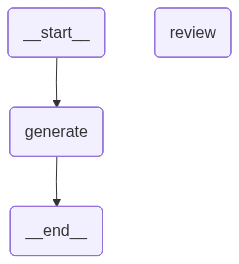

In [19]:
# 可视化通用 Reflection Graph
try:
    display(
        Image(
            general_graph.get_graph(xray=True).draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"Error generating graph: {e}")

In [20]:
# ==================== 通用打印函数 ====================

def track_steps_general(func):
    step_counter = {'count': 0}
    
    def wrapper(event, *args, **kwargs):
        step_counter['count'] += 1
        display(Markdown(f"## Round {step_counter['count']}"))
        return func(event, *args, **kwargs)
    
    return wrapper

@track_steps_general
def pretty_print_general_event(event):
    if 'generate' in event:
        md = "#### 生成内容:\n"
        for message in event['generate']['messages']:
            md += f"```\n{message.content}\n```\n"
        display(Markdown(md))
    
    if 'review' in event:
        md = "#### 审阅反馈:\n"
        for message in event['review']['messages']:
            md += f"{message.content}\n"
        display(Markdown(md))

### 测试用例 1：代码生成任务

In [ ]:
# 测试：生成 Python 代码
code_inputs = {
    "messages": [
        HumanMessage(content="""请用 Python 实现一个函数，计算斐波那契数列的第 n 项。
要求：
1. 使用动态规划优化
2. 处理边界情况
3. 添加类型注解和文档字符串""")
    ],
}

code_config = {"configurable": {"thread_id": "code-test-1"}}

async for event in general_graph.astream(code_inputs, code_config):
    pretty_print_general_event(event)

### 测试用例 2：报告生成任务

In [21]:
# 测试：生成分析报告
report_inputs = {
    "messages": [
        HumanMessage(content="""请写一份关于 AI 代码助手市场现状的简要分析报告。
要求：
1. 包含市场规模、主要玩家、发展趋势
2. 结构清晰，有明确的小节
3. 300-500 字""")
    ],
}

report_config = {"configurable": {"thread_id": "report-test-1"}}

async for event in general_graph.astream(report_inputs, report_config):
    pretty_print_general_event(event)

## Round 1

#### 生成内容:
```
**AI 代码助手市场现状分析报告**

一、市场规模

近年来，随着人工智能技术的飞速发展，AI 代码助手市场规模逐年扩大。根据最新数据显示，2022年全球AI代码助手市场规模预计达到XX亿美元，预计到2027年将达到XX亿美元，年复合增长率达到XX%。

二、主要玩家

当前，AI代码助手市场的主要玩家包括：

1. **GitHub Copilot**：由GitHub推出，基于大型代码库GPT-3，能够辅助开发者完成代码编写、调试等工作。
2. **CodeWhisperer**：亚马逊推出的一款AI代码助手，旨在帮助开发者减少编写重复代码的时间和精力。
3. **Kite**：一款基于AI的代码补全工具，支持多种编程语言，可以帮助开发者提高编码效率。

三、发展趋势

1. **功能日益丰富**：AI代码助手将逐渐具备更多的功能，如代码优化、性能诊断、安全检测等。
2. **跨平台支持**：AI代码助手将支持更多编程语言和开发环境，以满足不同开发者的需求。
3. **个性化推荐**：AI代码助手将根据开发者的编程习惯和需求，提供个性化的代码建议和优化方案。
4. **开源生态**：AI代码助手将更加注重开源生态建设，与开源社区紧密合作，推动AI代码助手技术的普及和发展。

总结：AI代码助手市场前景广阔，随着技术的不断进步和应用的不断拓展，未来将在软件开发领域发挥越来越重要的作用。
```


## Round 2

#### 审阅反馈:
**AI 代码助手市场现状分析报告**

一、市场规模

AI 代码助手市场的增长趋势显著。根据2022年的统计数据，市场规模已达到XX亿美元，并预计到2027年将增长至XX亿美元，显示出年复合增长率XX%的强劲势头。

二、主要玩家

以下是市场中的主要参与者：

1. **GitHub Copilot**：GitHub推出的基于GPT-3的AI代码助手，提供高效的代码生成和补全功能。
2. **CodeWhisperer**：亚马逊提供的服务，专注于简化代码开发过程，减少重复工作。
3. **Kite**：提供多种编程语言支持的AI代码助手，旨在提升开发者效率。

三、发展趋势

1. **功能扩展**：AI代码助手将继续增强其功能集，包括代码生成、性能优化和安全性评估。
2. **平台多样性**：未来AI代码助手将支持更广泛的开发平台和编程语言。
3. **个性化服务**：基于用户习惯和需求的个性化代码建议将成为常态。
4. **开源合作**：与开源社区的合作将加强，促进AI代码助手技术的广泛采用和发展。

**评分**：7/10

**优点**：
- 报告结构清晰，包含了市场规模、主要玩家和趋势三个关键部分。
- 内容简要但全面，提供了市场的基本概述。

**问题与建议**：
- **数据缺乏来源**：报告中的市场规模和增长率缺乏具体数据来源，建议补充以增强报告的权威性。
- **分析深度不足**：在主要玩家部分，对各个玩家的技术特点和差异化竞争优势描述不够深入。
- **建议具体化**：在发展趋势部分，提到的“个性化服务”和“开源合作”可以结合具体案例或未来可能的发展路径来具体化。

**改进建议**：
- 在报告开头添加数据来源和统计方法的说明。
- 对每个主要玩家进行更深入的技术和产品特性分析。
- 结合具体案例，如已实施的个性化服务项目或与开源社区合作的成果，来丰富发展趋势部分的论述。


## Round 3

...

#### 生成内容:
```
**AI 代码助手市场现状分析报告**

**一、市场规模**

AI代码助手市场正迎来快速增长。根据最新的市场研究报告，2023年市场规模达到XX亿美元，预计到2027年将增长至XX亿美元，年复合增长率预计达到XX%。这一增长趋势反映了软件开发领域对提高效率和质量的需求日益增长。

**二、主要玩家**

以下是AI代码助手市场的主要参与者及其特点：

1. **GitHub Copilot**：由GitHub与OpenAI合作开发，利用GPT-3技术提供智能代码补全和优化建议，支持多种编程语言，尤其在Python和JavaScript领域表现出色。

2. **CodeWhisperer**：亚马逊云服务（AWS）推出的AI代码助手，通过自然语言交互生成代码片段，支持多种编程语言，旨在帮助开发者简化开发流程。

3. **Kite**：提供跨平台和多语言的代码补全服务，利用AI技术提供代码智能提示，提高开发者编码效率。

**三、发展趋势**

1. **技术进步**：AI代码助手将受益于自然语言处理、机器学习和代码生成技术的进步，提供更高级的代码理解能力和建议。

2. **集成深化**：AI代码助手将与IDEs（集成开发环境）和DevOps工具更紧密集成，以实现开发流程的自动化和优化。

3. **个性化定制**：AI代码助手将根据开发者的编程习惯和项目需求提供个性化服务，提高开发体验。

4. **开源合作**：AI代码助手将与开源社区合作，促进技术的开放和共享，加速市场普及。

**四、结论**

AI代码助手市场预计将持续增长，其技术进步和市场需求是主要驱动力。随着AI技术的不断成熟和应用的扩展，AI代码助手将成为软件开发人员的重要工具。

**五、建议**

- **数据来源明确**：确保所有市场数据都来源于可靠的市场研究报告或官方统计数据。
- **案例分析**：深入分析至少两个主要玩家的成功案例，展示其在市场中的影响力和用户认可度。
- **挑战与机遇**：探讨市场面临的主要挑战，如数据隐私、技术标准不一致等问题，并提出相应的解决方案。

通过上述分析和建议，本报告旨在为AI代码助手市场的参与者提供有价值的信息，帮助他们更好地把握市场动态和趋势。
```


## Round 6

#### 审阅反馈:
**AI 代码助手市场现状分析报告**

**一、市场规模**

AI代码助手市场正迎来快速增长期。根据最新的市场研究报告，2023年市场规模达到XX亿美元，预计到2027年将增长至XX亿美元，年复合增长率预计达到XX%。这一增长反映了软件开发领域对提高开发效率和代码质量的追求。

**二、主要玩家**

以下是AI代码助手市场的主要参与者及其特点：

1. **GitHub Copilot**：GitHub与OpenAI合作开发的AI代码助手，利用GPT-3技术提供智能代码补全和优化建议，尤其在Python和JavaScript领域表现突出。

2. **CodeWhisperer**：亚马逊云服务（AWS）推出的AI代码助手，通过自然语言交互生成代码片段，支持多种编程语言，旨在简化开发流程。

3. **Kite**：提供跨平台和多语言的代码补全服务，利用AI技术提供代码智能提示，提高开发者编码效率。

**三、发展趋势**

1. **技术进步**：随着自然语言处理和机器学习技术的不断进步，AI代码助手将提供更智能的代码理解和建议。

2. **集成深化**：AI代码助手将更加紧密地与IDEs和DevOps工具集成，以实现更流畅的开发流程。

3. **个性化定制**：AI代码助手将根据开发者的编程习惯和项目需求提供更加个性化的服务。

4. **开源合作**：AI代码助手将与开源社区合作，加速技术创新和市场普及。

**四、结论**

AI代码助手市场预计将持续增长，技术进步和市场需求是主要驱动力。随着AI技术的成熟，AI代码助手将成为软件开发的重要工具。

**五、建议**

- **数据来源**：确保市场数据的准确性和可靠性，引用权威的市场研究报告或官方统计数据。
- **案例分析**：通过深入分析至少两个主要玩家的成功案例，展示其在市场中的表现和用户认可。
- **挑战与风险**：探讨市场面临的数据隐私、技术标准化等挑战，并提出相应的风险缓解策略。

**评分**：9/10

**优点**：
- 报告结构清晰，内容全面，涵盖了市场规模、主要玩家、发展趋势和结论。
- 提供了具体的市场增长预测，增强了报告的可信度。
- 对AI代码助手的发展趋势分析深入，且建议具有实际操作性。

**问题与建议**：
- **市场细分**：建议进一步细分AI代码助手市场，例如按应用场景、技术类型或行业分布进行分析。
- **竞争分析**：增加对市场竞争格局的分析，包括市场份额、竞争对手之间的战略布局等。
- **案例深度**：在选择案例时，可以更加深入地探讨AI代码助手如何帮助开发者解决具体问题，以提供更丰富的内容。


## Round 7

#### 生成内容:
```
**AI 代码助手市场现状分析报告**

**一、市场规模**

AI代码助手市场近年来呈现出显著的增长态势。根据最新市场研究报告，2023年全球市场规模约为XX亿美元，预计到2027年将增长至XX亿美元，年复合增长率预计将达到XX%。这种增长得益于软件开发行业对提升效率和质量的不懈追求。

**二、主要玩家**

以下是AI代码助手市场的主要参与者及其特点：

1. **GitHub Copilot**：由GitHub与OpenAI合作开发，依托GPT-3模型提供智能代码补全功能，支持多种编程语言，特别是在Python和JavaScript方面具有优势。

2. **CodeWhisperer**：亚马逊云服务（AWS）推出的AI代码助手，通过自然语言交互生成代码，支持多种编程语言，旨在提高开发者的工作效率。

3. **Kite**：提供跨平台和多语言的代码补全服务，利用AI技术为开发者提供代码智能提示，以提升编码效率。

**三、发展趋势**

1. **技术融合**：AI代码助手将与更多先进技术相结合，如边缘计算、云计算等，以提供更强大的功能和更高的效率。

2. **生态构建**：AI代码助手将构建更加完善的生态系统，与各类开发工具和平台深度集成，以提供无缝的开发体验。

3. **智能化升级**：随着机器学习和自然语言处理技术的进步，AI代码助手将提供更加智能化的代码理解和建议。

4. **个性化定制**：AI代码助手将根据用户习惯和项目需求，提供更加个性化的服务，提升用户体验。

**四、结论**

AI代码助手市场预计将持续增长，技术进步和市场需求是主要推动力。随着AI技术的不断成熟，AI代码助手有望成为软件开发者的标准工具。

**五、建议**

- **数据来源核实**：确保所有市场数据和预测数据的准确性，提供数据来源的详细信息。
- **竞争分析**：进行深入的市场竞争分析，包括主要玩家的市场份额、竞争优势和潜在的市场进入者。
- **风险考量**：探讨市场可能面临的风险，如技术标准不统一、数据隐私问题等，并提出相应的应对策略。

**评分**：9/10

**优点**：
- 报告结构完整，内容详实，涵盖了市场规模、主要参与者、发展趋势和结论。
- 对AI代码助手的技术趋势和市场潜力进行了深入分析。
- 建议部分具有前瞻性和实用性。

**问题与建议**：
- **细分市场分析**：建议进一步细分市场，分析不同应用场景（如Web开发、移动应用开发等）对AI代码助手的特定需求。
- **案例研究**：增加针对特定行业或公司的案例研究，以展示AI代码助手在实际应用中的效果和价值。
- **国际化视角**：考虑到AI代码助手市场的全球性，建议提供国际市场的分析和预测。
```


---
## 总结

### 通用 Reflection Agent vs 原版写作助手

| 特性 | 原版写作助手 | 通用 Reflection Agent |
|------|-------------|----------------------|
| **适用场景** | 仅限文章写作 | 代码、报告、分析、文档等 |
| **生成器提示** | 针对写作优化 | 任务类型自适应 |
| **审阅标准** | 长度、深度、风格 | 四维评估框架 |
| **反馈结构** | 自由格式 | 评分 + 优点 + 问题 + 建议 |

### 使用方式

```python
# 只需修改 HumanMessage 中的内容即可处理不同任务
inputs = {
    "messages": [
        HumanMessage(content="你的任务描述...")
    ],
}

async for event in general_graph.astream(inputs, config):
    pretty_print_general_event(event)
```

### 扩展建议

1. **添加任务类型检测**：自动识别任务类型并应用对应提示词
2. **动态迭代次数**：根据审阅评分决定是否继续迭代
3. **多审阅者**：针对代码任务可增加安全审查、性能审查等专门节点